In [1]:
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.style.use('bmh')
import pandas as pd
import statsmodels.api as sm
import matplotlib

In [4]:
df1997 = pd.read_csv("tsv/faces_objects-1997.tsv", sep='\t')#, skiprows = 1)

In [5]:
df1997.head()

,time,faces,square_faces,objects
0,0:0:0,0,0.0,0
1,0:0:2,0,0.0,0
2,0:0:4,0,0.0,84
3,0:0:6,0,0.0,271
4,0:0:8,0,0.0,68


In [10]:
df1997['time'] = pd.to_datetime(df1997['time'], format='%H:%M:%S')

In [11]:
df1997.head()

,time,faces,square_faces,objects
0,1900-01-01 00:00:00,0,0.0,0
1,1900-01-01 00:00:02,0,0.0,0
2,1900-01-01 00:00:04,0,0.0,84
3,1900-01-01 00:00:06,0,0.0,271
4,1900-01-01 00:00:08,0,0.0,68


In [12]:
ts1997 = df1997.set_index('time')

In [13]:
ts1997.index

DatetimeIndex(['1900-01-01 00:00:00', '1900-01-01 00:00:02',
               '1900-01-01 00:00:04', '1900-01-01 00:00:06',
               '1900-01-01 00:00:08', '1900-01-01 00:00:10',
               '1900-01-01 00:00:12', '1900-01-01 00:00:14',
               '1900-01-01 00:00:16', '1900-01-01 00:00:18',
               ...
               '1900-01-01 01:47:28', '1900-01-01 01:47:30',
               '1900-01-01 01:47:32', '1900-01-01 01:47:34',
               '1900-01-01 01:47:36', '1900-01-01 01:47:38',
               '1900-01-01 01:47:40', '1900-01-01 01:47:42',
               '1900-01-01 01:47:44', '1900-01-01 01:47:46'],
              dtype='datetime64[ns]', name='time', length=3234, freq=None)

In [16]:
y = ts1997['objects']#.resample('MS').mean()

In [46]:
plt.style.use('bmh')

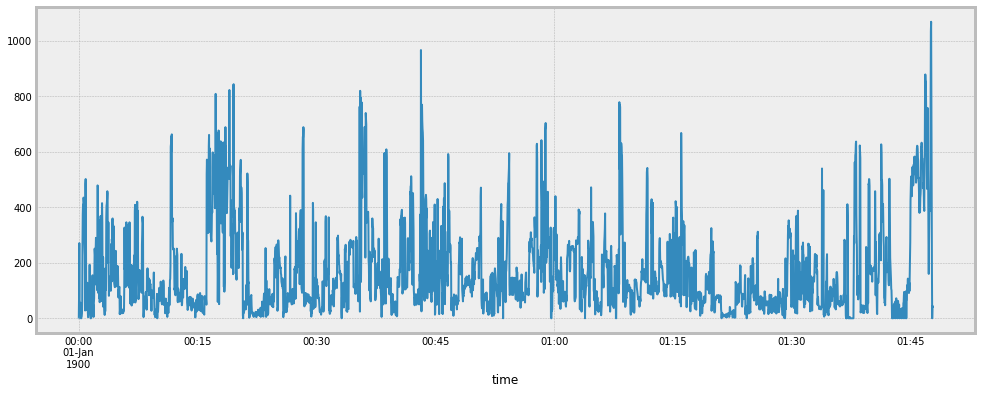

In [47]:
y.plot(figsize=(15, 6))
plt.show()

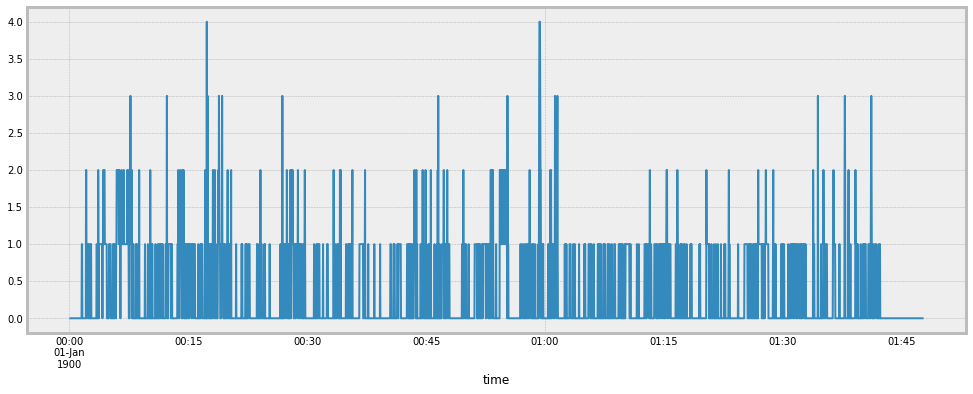

In [48]:
y1 = ts1997['faces']
y1.plot(figsize=(15, 6))
plt.show()

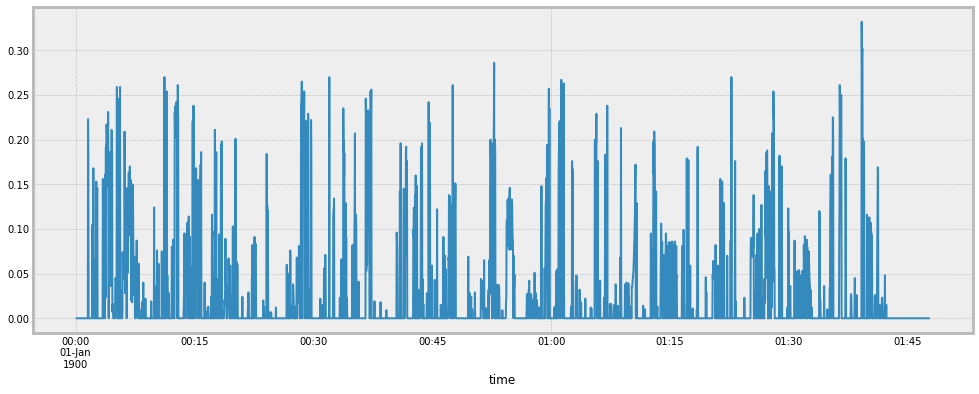

In [49]:
y1 = ts1997['square_faces']
y1.plot(figsize=(15, 6))
plt.show()

In [21]:
np.corrcoef(ts1997['objects'], ts1997['square_faces'])

array([[ 1.        , -0.17789462],
       [-0.17789462,  1.        ]])

In [23]:
%matplotlib inline 

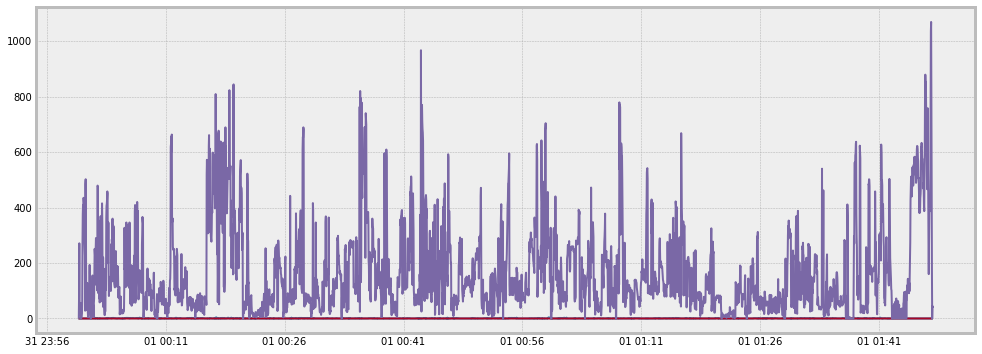

In [50]:
plt.plot(ts1997)

In [39]:
from pylab import rcParams

In [40]:
rcParams['figure.figsize'] = 15, 6

In [59]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    
    #Determing rolling statistics
    #rolmean = pd.rolling_mean(timeseries, window=12)
    rolmean = timeseries.rolling(60).mean()
    #rolstd = pd.rolling_std(timeseries, window=12)
    rolstd = timeseries.rolling(60).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.title('Rolling Mean')
    plt.show(block=False)
              
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.title('Standard Deviation')
    plt.show(block=False)
    
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

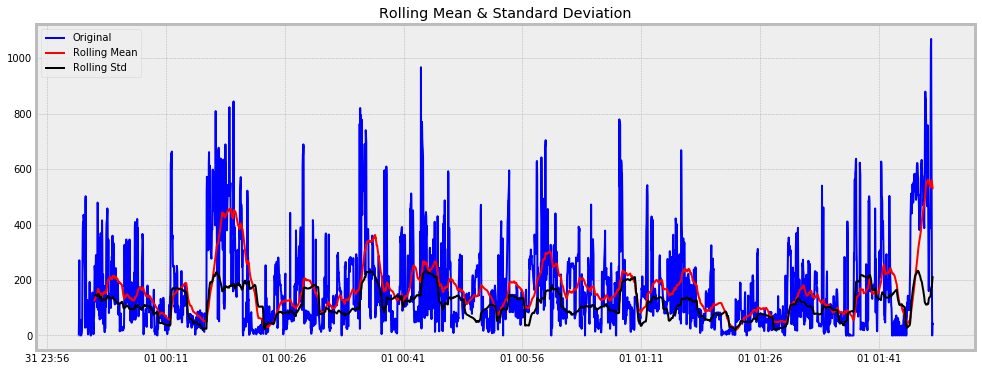

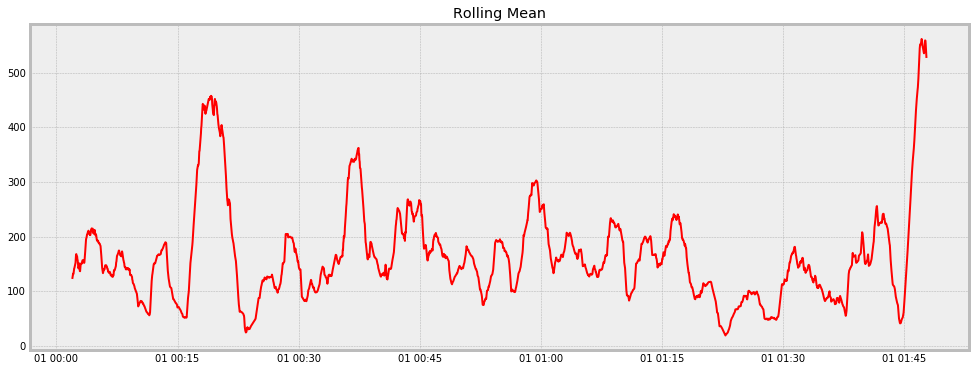

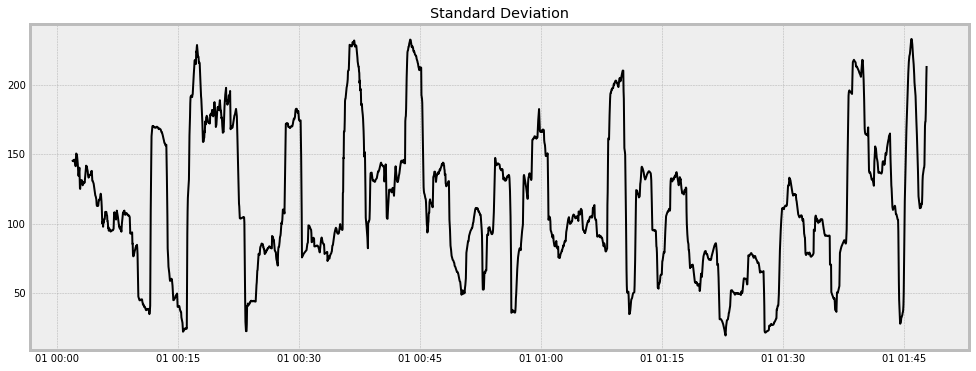

Results of Dickey-Fuller Test:
Test Statistic                -9.144266e+00
p-value                        2.795370e-15
#Lags Used                     9.000000e+00
Number of Observations Used    3.224000e+03
Critical Value (5%)           -2.862437e+00
Critical Value (10%)          -2.567247e+00
Critical Value (1%)           -3.432380e+00
dtype: float64


In [60]:
test_stationarity(ts1997['objects'])

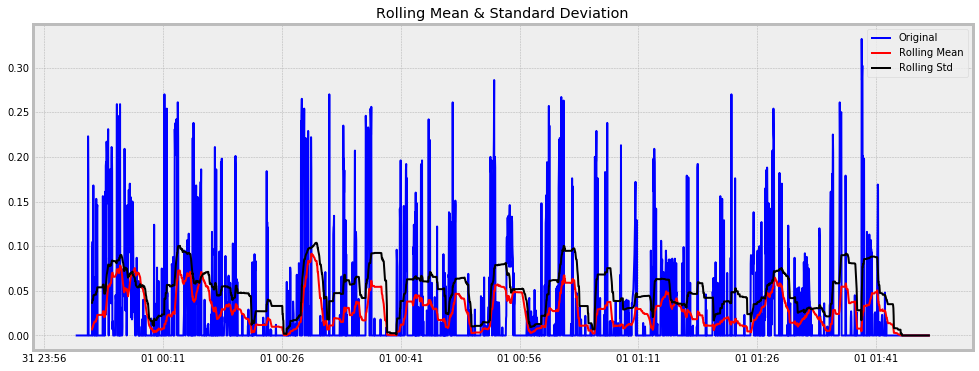

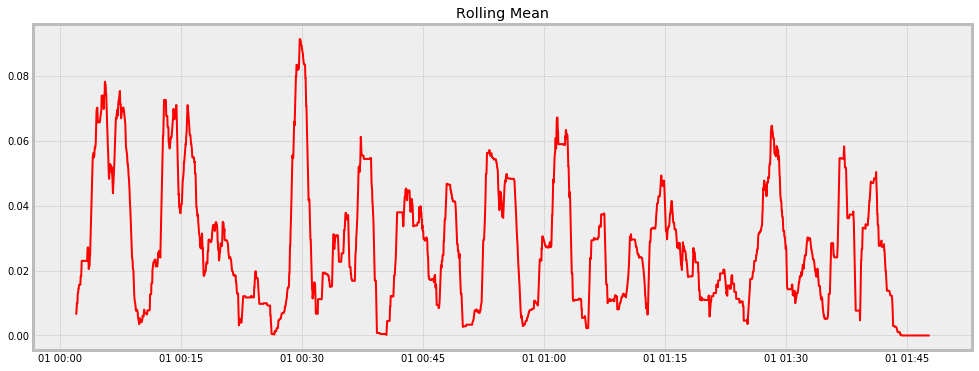

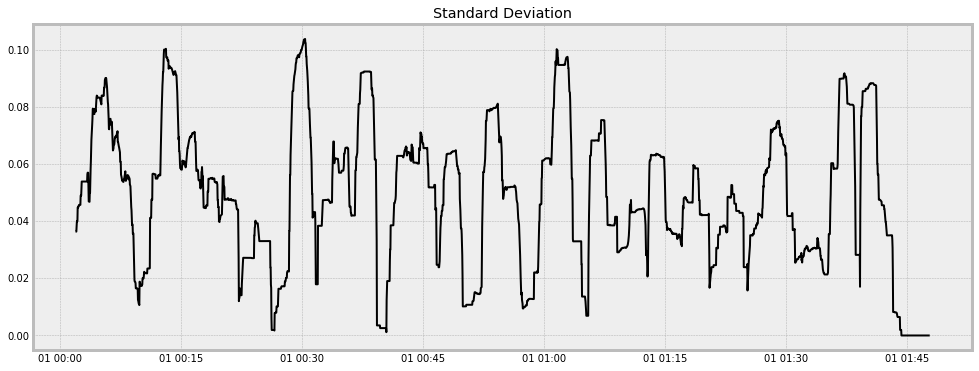

Results of Dickey-Fuller Test:
Test Statistic                -1.228815e+01
p-value                        7.938619e-23
#Lags Used                     9.000000e+00
Number of Observations Used    3.224000e+03
Critical Value (5%)           -2.862437e+00
Critical Value (10%)          -2.567247e+00
Critical Value (1%)           -3.432380e+00
dtype: float64


In [61]:
test_stationarity(ts1997['square_faces'])

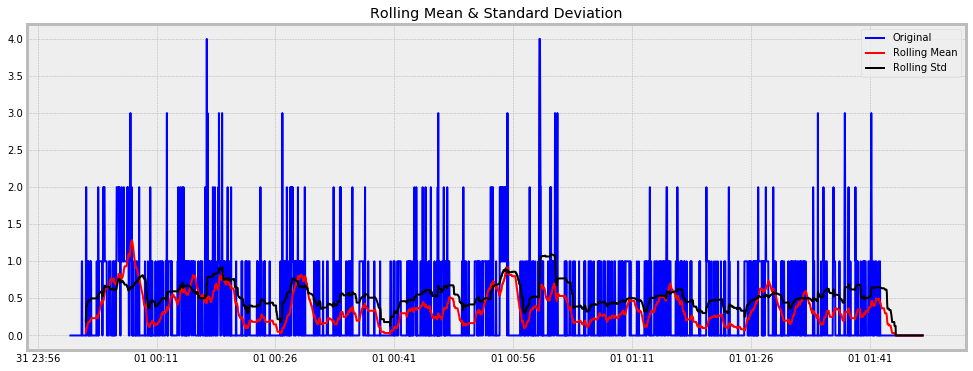

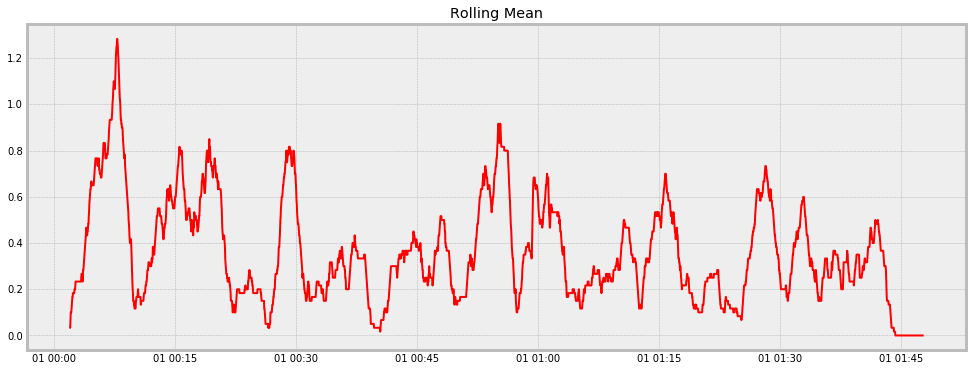

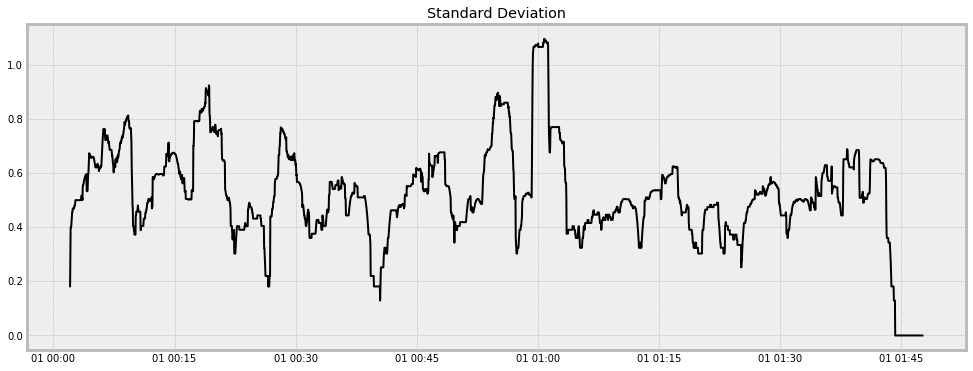

Results of Dickey-Fuller Test:
Test Statistic                -1.042141e+01
p-value                        1.700860e-18
#Lags Used                     1.300000e+01
Number of Observations Used    3.220000e+03
Critical Value (5%)           -2.862438e+00
Critical Value (10%)          -2.567248e+00
Critical Value (1%)           -3.432382e+00
dtype: float64


In [62]:
test_stationarity(ts1997['faces'])

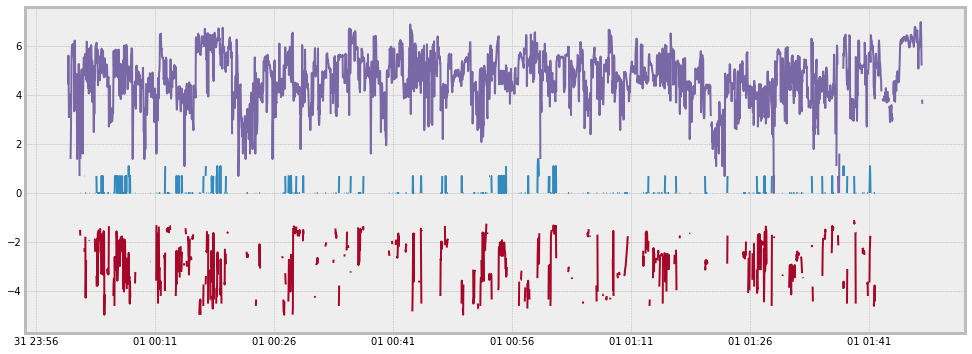

In [54]:
ts_log = np.log(ts1997)
plt.plot(ts_log)

In [79]:
def test_stationarity2(timeseries):
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(240).mean()
    rolstd = timeseries.rolling(240).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

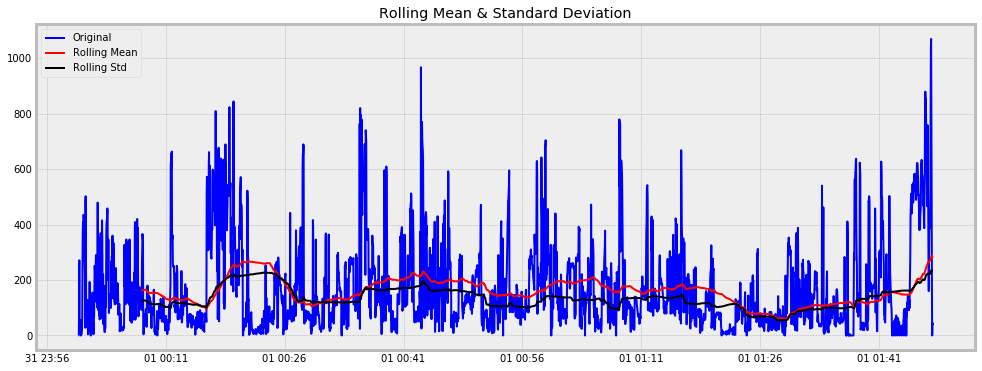

In [80]:
test_stationarity2(ts1997['objects'])

# 1967

In [63]:
df1967 = pd.read_csv("tsv/faces_objects-1967.tsv", sep='\t')

In [64]:
df1967['time'] = pd.to_datetime(df1967['time'], format='%H:%M:%S')

In [65]:
ts1967 = df1967.set_index('time')

In [66]:
np.corrcoef(ts1967['objects'], ts1967['square_faces'])

array([[ 1.        , -0.13662205],
       [-0.13662205,  1.        ]])

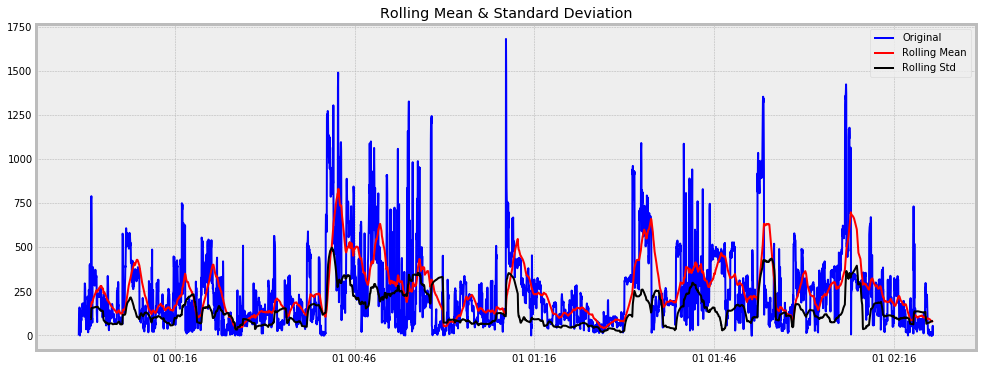

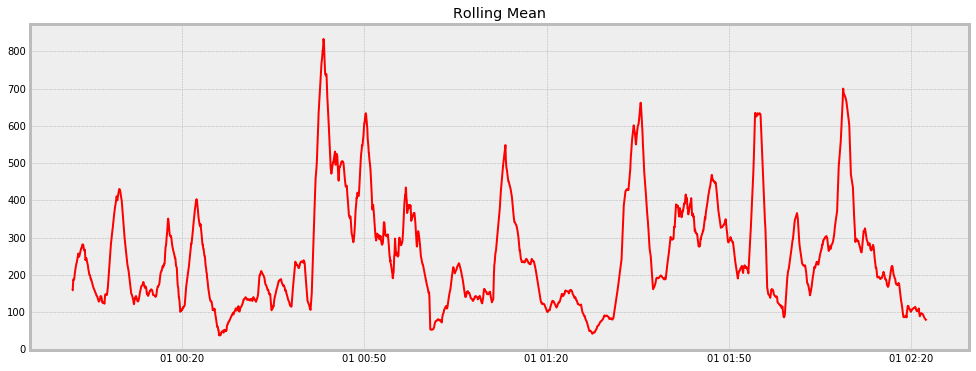

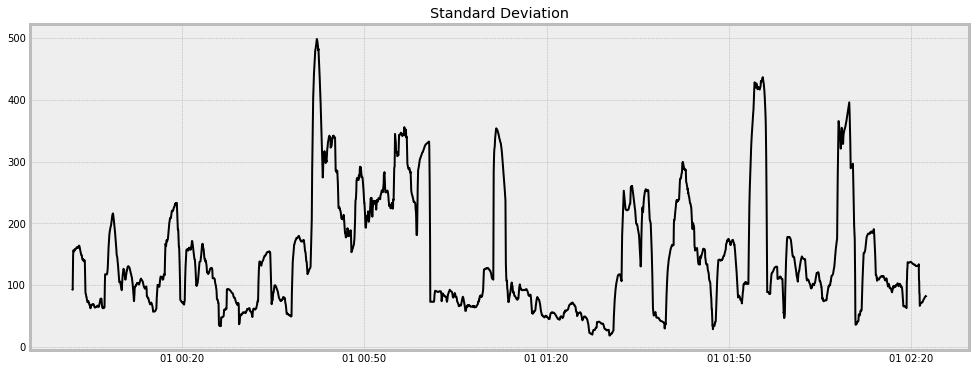

Results of Dickey-Fuller Test:
Test Statistic                -7.174652e+00
p-value                        2.747267e-10
#Lags Used                     2.700000e+01
Number of Observations Used    4.248000e+03
Critical Value (5%)           -2.862221e+00
Critical Value (10%)          -2.567132e+00
Critical Value (1%)           -3.431890e+00
dtype: float64


In [67]:
test_stationarity(ts1967['objects'])

## Анализ цветов

![colors](spectrum-1967.jpg)

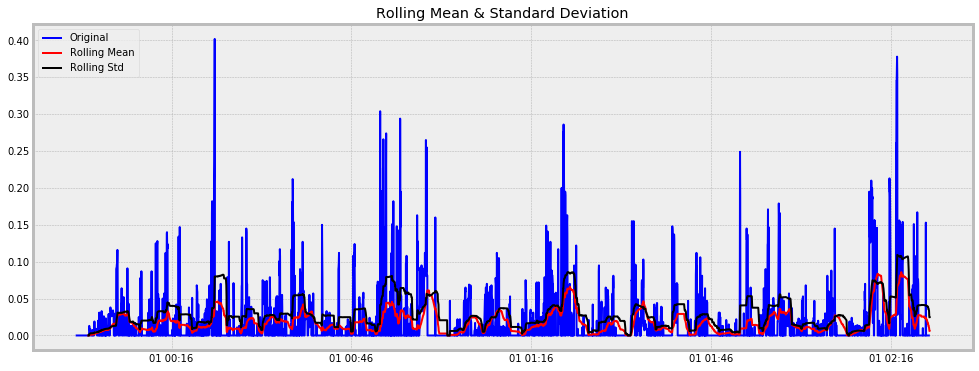

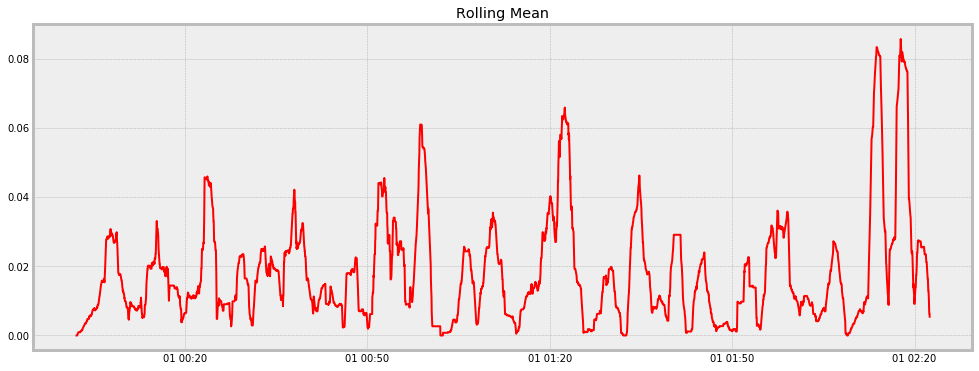

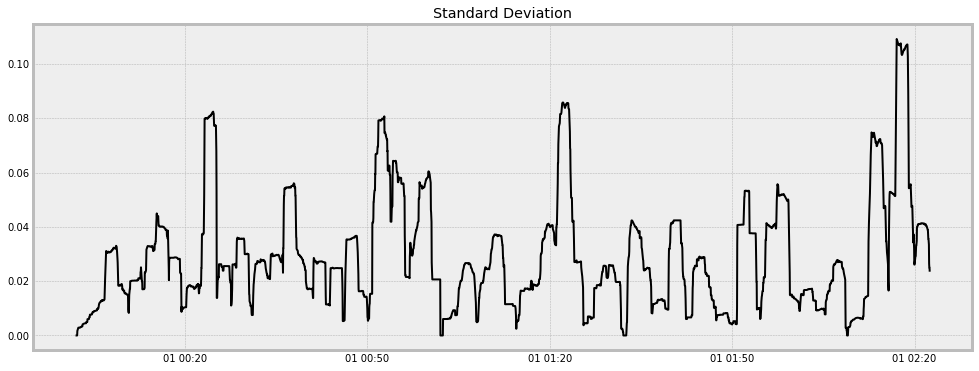

Results of Dickey-Fuller Test:
Test Statistic                -1.100839e+01
p-value                        6.417239e-20
#Lags Used                     1.800000e+01
Number of Observations Used    4.257000e+03
Critical Value (5%)           -2.862219e+00
Critical Value (10%)          -2.567132e+00
Critical Value (1%)           -3.431887e+00
dtype: float64


In [68]:
test_stationarity(ts1967['square_faces'])

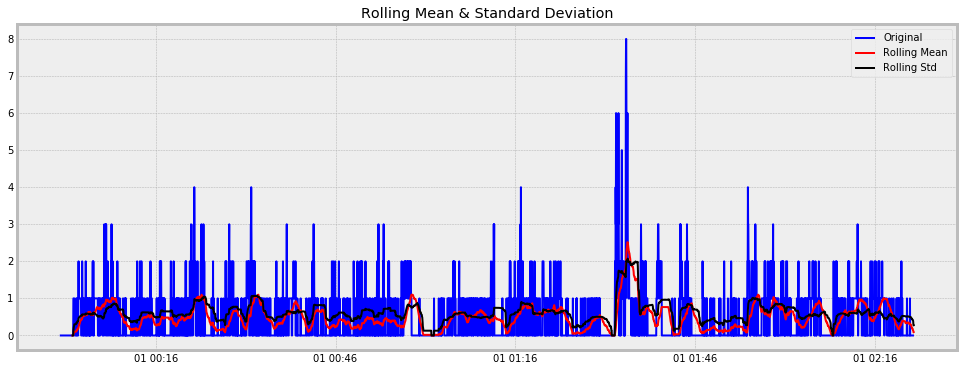

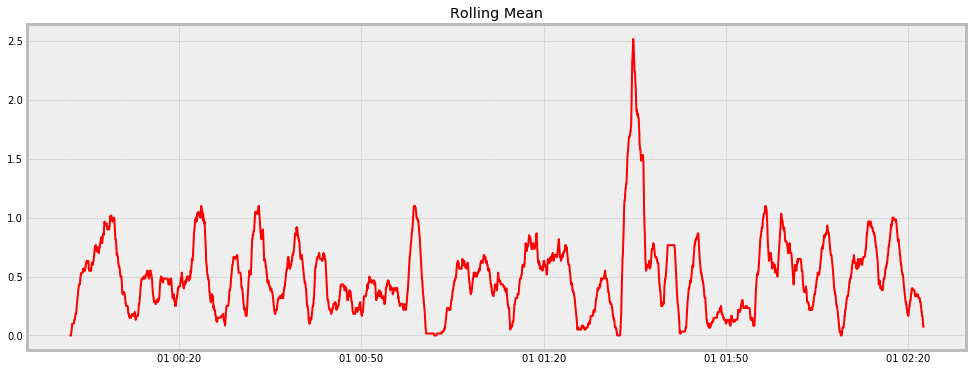

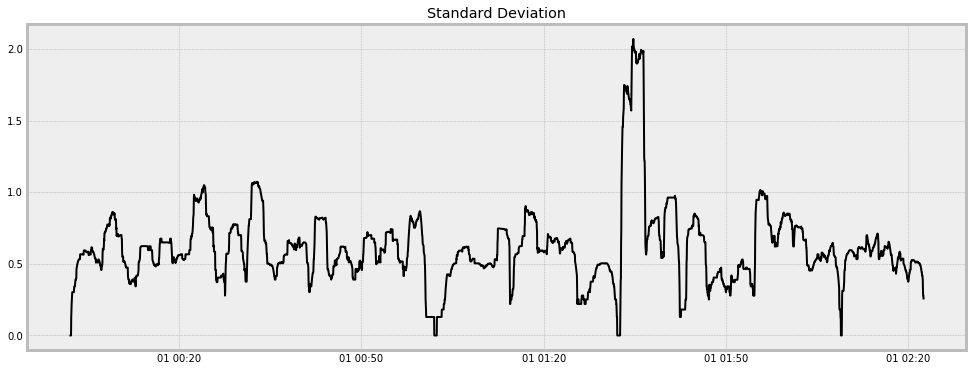

Results of Dickey-Fuller Test:
Test Statistic                -1.100713e+01
p-value                        6.461729e-20
#Lags Used                     1.300000e+01
Number of Observations Used    4.262000e+03
Critical Value (5%)           -2.862218e+00
Critical Value (10%)          -2.567131e+00
Critical Value (1%)           -3.431885e+00
dtype: float64


In [69]:
test_stationarity(ts1967['faces'])

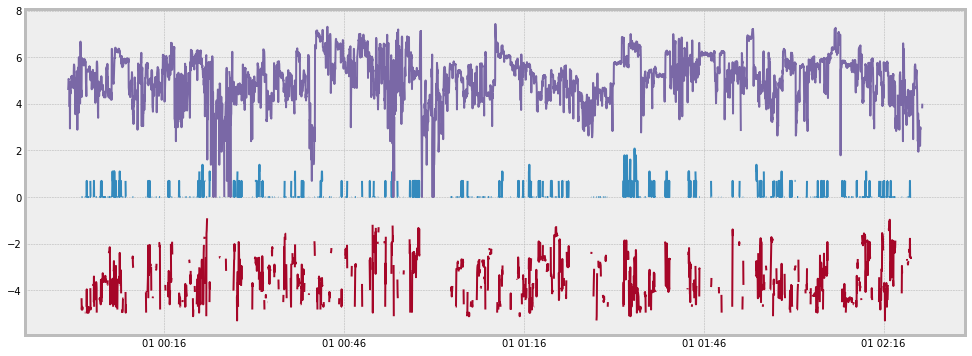

In [70]:
ts_log = np.log(ts1967)
plt.plot(ts_log)

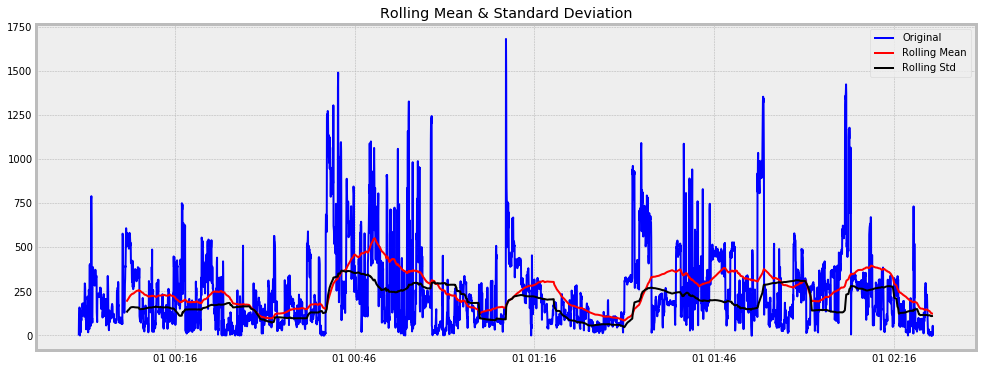

In [81]:
test_stationarity2(ts1967['objects'])

# 1935

In [71]:
df1935 = pd.read_csv("tsv/faces_objects-1935.tsv", sep='\t')
df1935['time'] = pd.to_datetime(df1935['time'], format='%H:%M:%S')
ts1935 = df1935.set_index('time')

In [72]:
np.corrcoef(ts1935['objects'], ts1935['square_faces'])

array([[ 1.        , -0.24854061],
       [-0.24854061,  1.        ]])

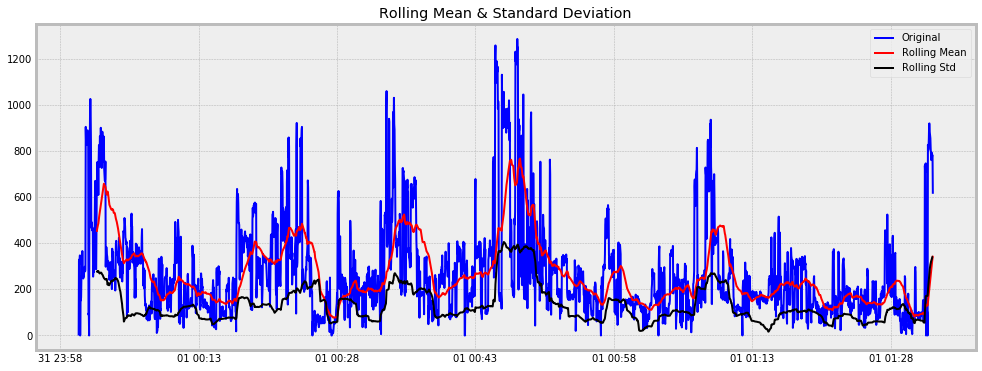

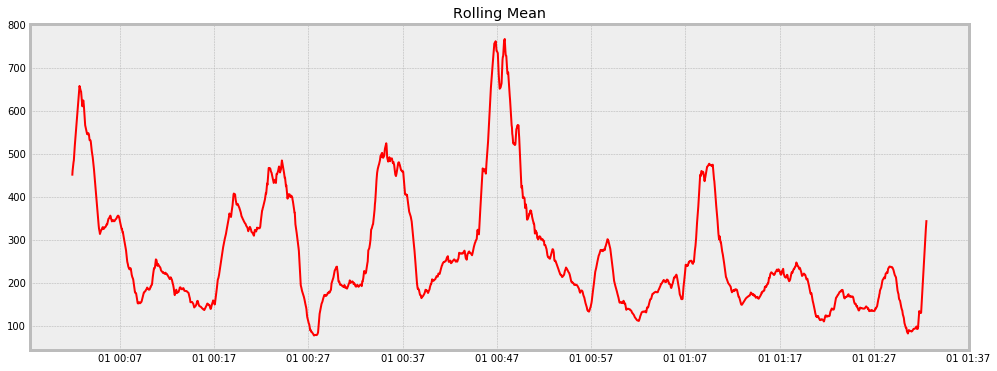

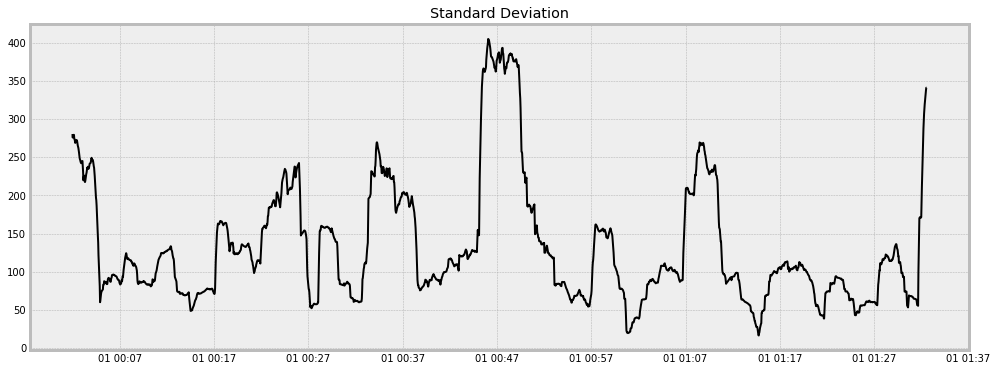

Results of Dickey-Fuller Test:
Test Statistic                   -5.249047
p-value                           0.000007
#Lags Used                       25.000000
Number of Observations Used    2752.000000
Critical Value (5%)              -2.862591
Critical Value (10%)             -2.567329
Critical Value (1%)              -3.432728
dtype: float64


In [73]:
test_stationarity(ts1935['objects'])

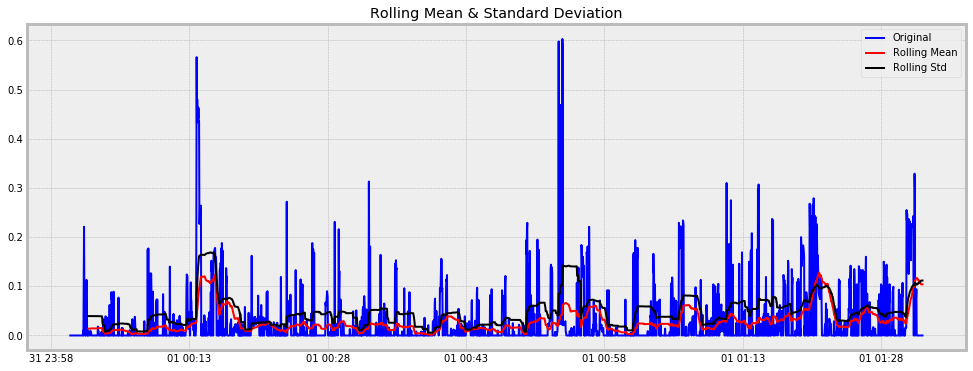

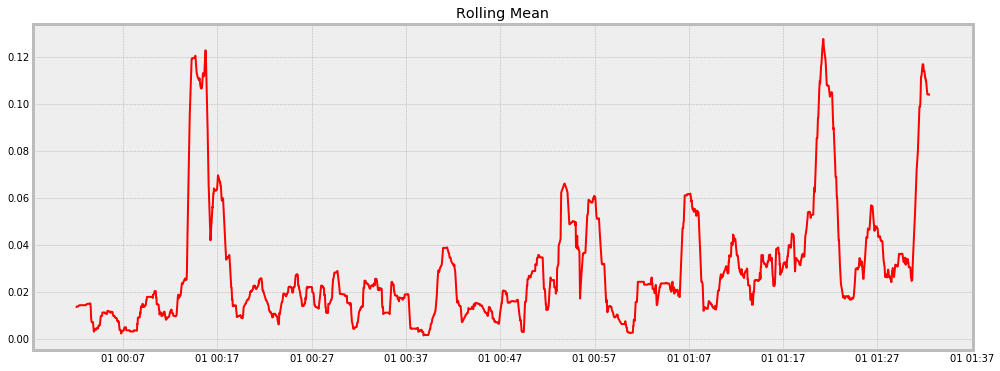

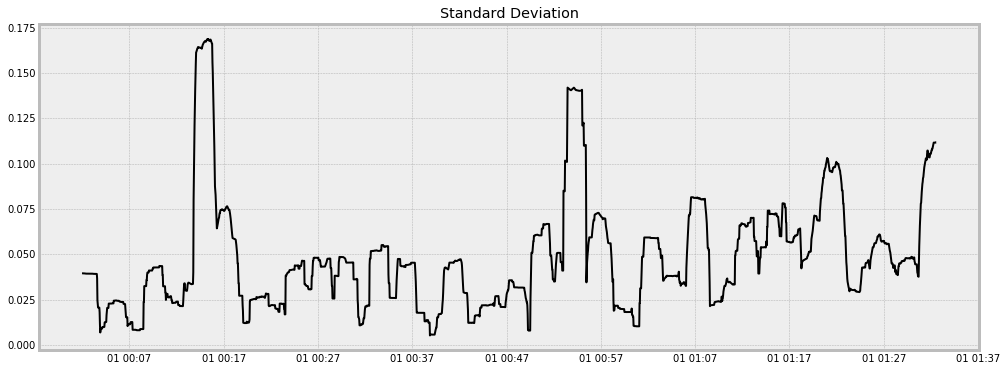

Results of Dickey-Fuller Test:
Test Statistic                -9.966315e+00
p-value                        2.302047e-17
#Lags Used                     1.300000e+01
Number of Observations Used    2.764000e+03
Critical Value (5%)           -2.862586e+00
Critical Value (10%)          -2.567327e+00
Critical Value (1%)           -3.432718e+00
dtype: float64


In [74]:
test_stationarity(ts1935['square_faces'])

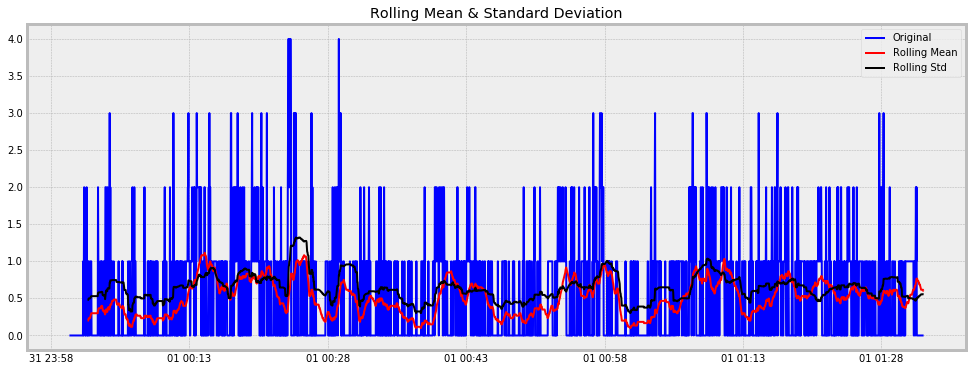

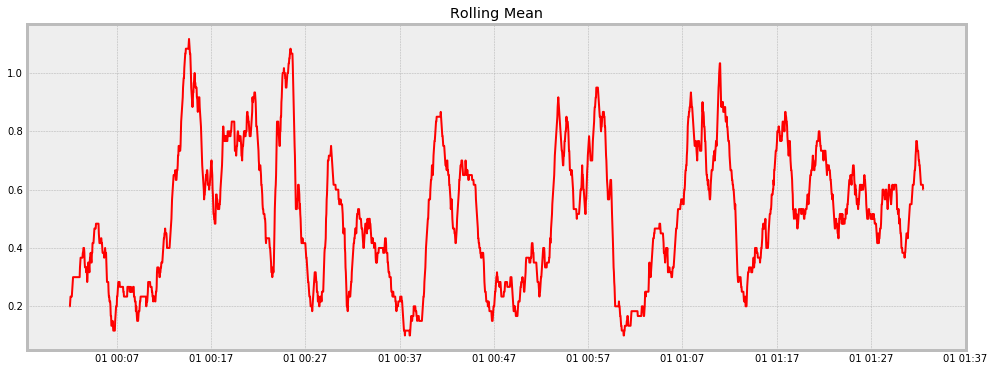

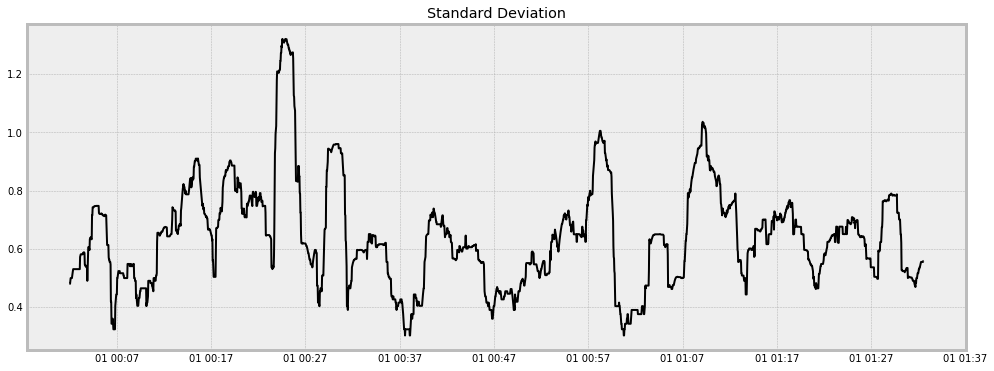

Results of Dickey-Fuller Test:
Test Statistic                -1.366138e+01
p-value                        1.519143e-25
#Lags Used                     6.000000e+00
Number of Observations Used    2.771000e+03
Critical Value (5%)           -2.862584e+00
Critical Value (10%)          -2.567326e+00
Critical Value (1%)           -3.432712e+00
dtype: float64


In [75]:
test_stationarity(ts1935['faces'])

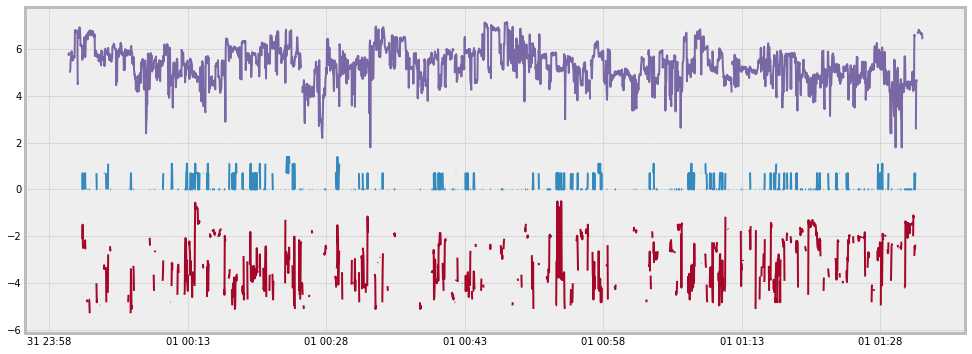

In [76]:
ts_log = np.log(ts1935)
plt.plot(ts_log)

In [ ]:
#df1935 = pd.read_csv("tsv/faces_objects-1935.tsv", sep='\t')
#df1935['time'] = pd.to_datetime(df1935['time'], format='%H:%M:%S')
#ts1935 = df1935.set_index('time')


#np.corrcoef(ts1935['objects'], ts1935['square_faces'])

#test_stationarity(ts1935['objects'])

#test_stationarity(ts1935['square_faces'])

#test_stationarity(ts1935['faces'])

#ts_log = np.log(ts1935)
#plt.plot(ts_log)

# 2017

In [82]:
df2017 = pd.read_csv("tsv/faces_objects-2017.tsv", sep='\t')
df2017['time'] = pd.to_datetime(df2017['time'], format='%H:%M:%S')
ts2017 = df2017.set_index('time')

In [83]:
np.corrcoef(ts2017['objects'], ts2017['square_faces'])

array([[ 1.        , -0.21054776],
       [-0.21054776,  1.        ]])

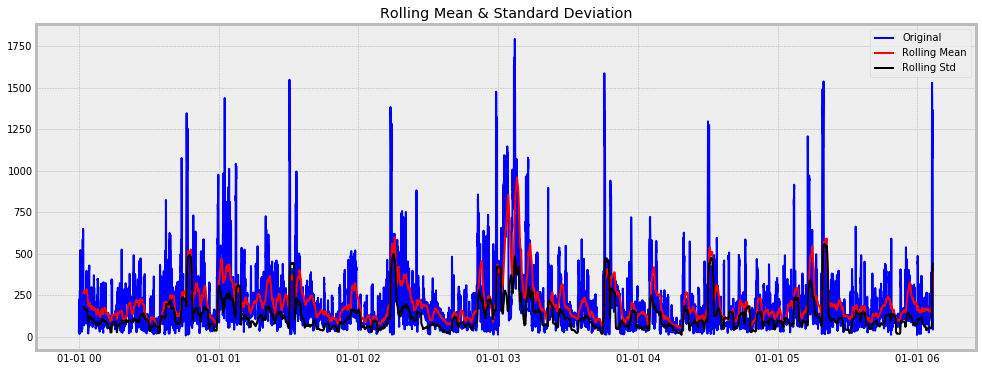

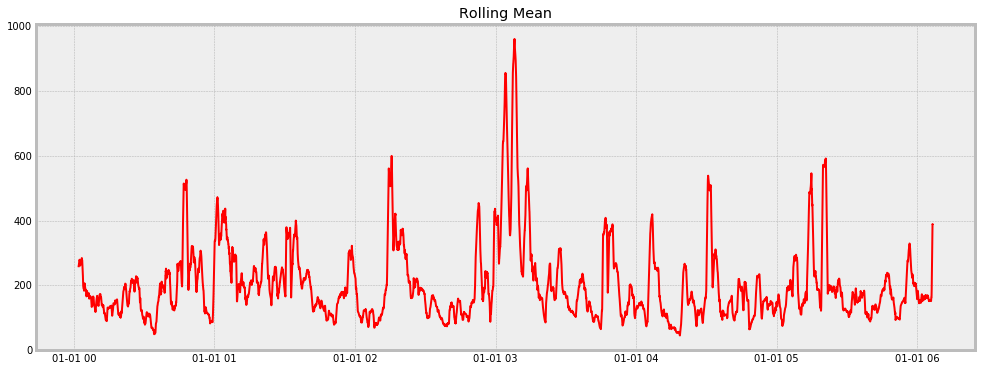

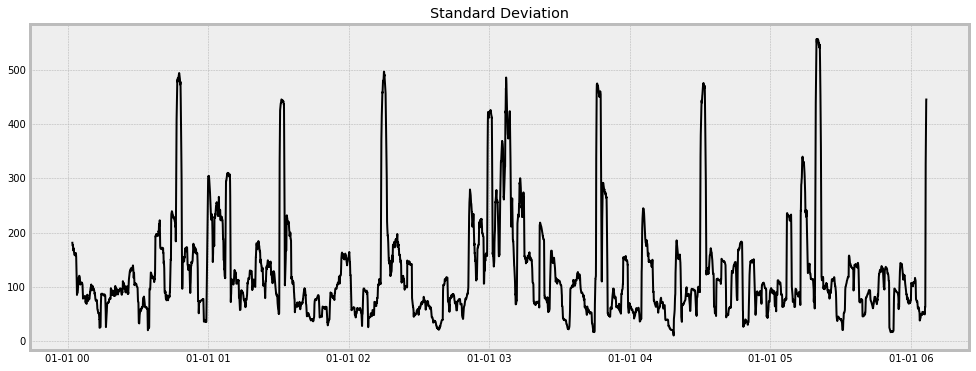

Results of Dickey-Fuller Test:
Test Statistic                -1.299403e+01
p-value                        2.774164e-24
#Lags Used                     2.400000e+01
Number of Observations Used    1.097600e+04
Critical Value (5%)           -2.861803e+00
Critical Value (10%)          -2.566910e+00
Critical Value (1%)           -3.430946e+00
dtype: float64


In [84]:
test_stationarity(ts2017['objects'])

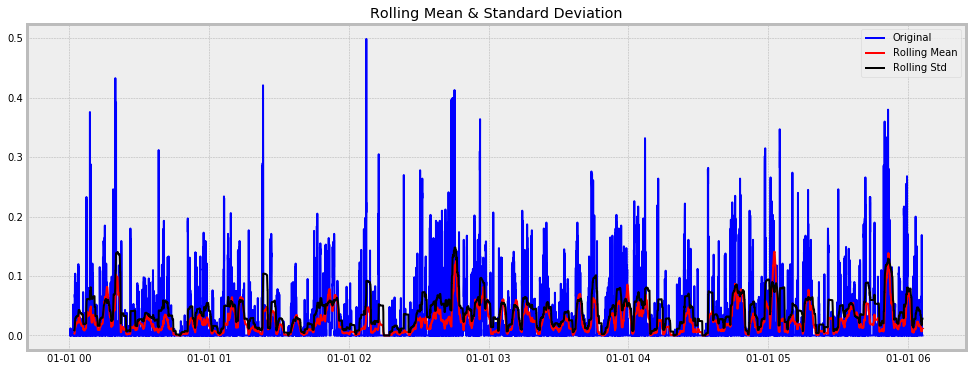

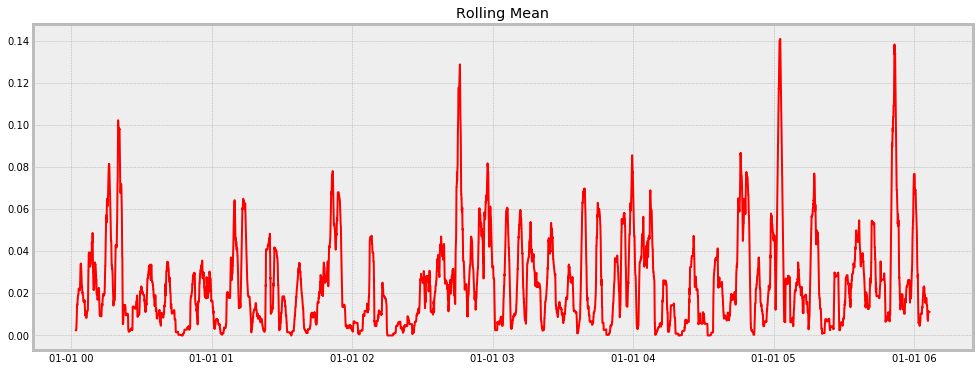

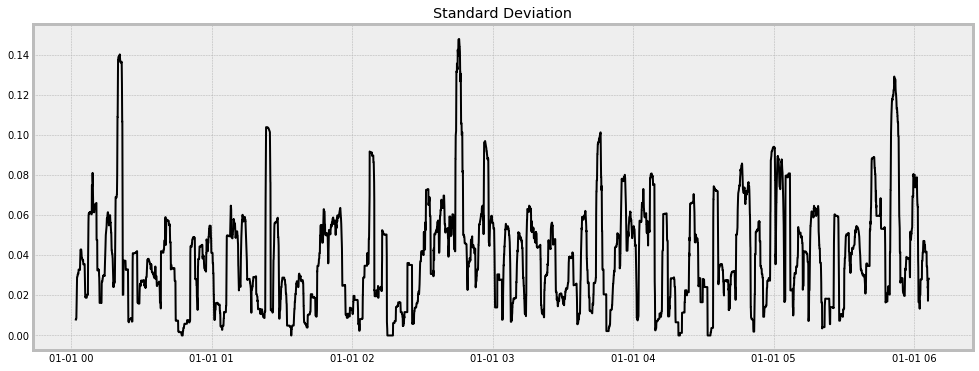

Results of Dickey-Fuller Test:
Test Statistic                -1.801771e+01
p-value                        2.701592e-30
#Lags Used                     1.600000e+01
Number of Observations Used    1.098400e+04
Critical Value (5%)           -2.861803e+00
Critical Value (10%)          -2.566910e+00
Critical Value (1%)           -3.430945e+00
dtype: float64


In [85]:
test_stationarity(ts2017['square_faces'])

In [86]:
# https://www.kaggle.com/kashnitsky/topic-9-part-1-time-series-analysis-in-python
# https://www.analyticsvidhya.com/blog/2016/02/time-series-forecasting-codes-python/